In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib

In [2]:
df = pd.read_csv("soccer_match_dataset_1000_balanced_v2.csv")
df.head(5)

,match_id,home_team,away_team,home_form_5g,away_form_5g,home_xg,away_xg,home_xga,away_xga,home_xt,...,travel_distance_away_km,h2h_home_win_ratio,missing_key_players_home,missing_key_players_away,referee_card_rate,weather_condition,kickoff_time_uk,home_goals,away_goals,result
0,M0001,Middlesbrough,Tottenham,0.07,0.16,3.70,4.73,3.09,4.77,4.74,...,73,0.34,5,7,4.7,Windy,20:00,1,1,1
1,M0002,Aston Villa,Middlesbrough,0.45,0.83,4.68,1.93,0.50,3.97,3.24,...,595,0.66,6,0,3.5,Overcast,16:30,2,1,2
2,M0003,Brentford,Chelsea,0.53,0.27,3.91,1.07,1.98,2.75,4.78,...,314,0.11,1,7,2.1,Rainy,19:45,2,0,2
3,M0004,Luton Town,Fulham,0.56,0.32,3.47,2.23,4.10,2.30,1.38,...,189,0.63,5,2,3.4,Windy,15:00,0,0,1
4,M0005,Brentford,Everton,0.16,0.07,1.19,1.37,2.18,1.05,2.57,...,777,0.04,2,5,3.9,Overcast,15:00,2,2,1


In [3]:
df['match_importance_home'].value_counts()

match_importance_home
Medium    347
High      339
Low       316
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   match_id                  1002 non-null   str    
 1   home_team                 1002 non-null   str    
 2   away_team                 1002 non-null   str    
 3   home_form_5g              1002 non-null   float64
 4   away_form_5g              1002 non-null   float64
 5   home_xg                   1002 non-null   float64
 6   away_xg                   1002 non-null   float64
 7   home_xga                  1002 non-null   float64
 8   away_xga                  1002 non-null   float64
 9   home_xt                   1002 non-null   float64
 10  away_xt                   1002 non-null   float64
 11  home_sot                  1002 non-null   float64
 12  away_sot                  1002 non-null   float64
 13  home_attack_strength      1002 non-null   float64
 14  away_attack_strengt

In [5]:
df.shape

(1002, 32)

In [6]:
df['result'].unique()

array([1, 2, 0])

In [7]:
df['weather_condition'].unique()

<ArrowStringArray>
['Windy', 'Overcast', 'Rainy', 'Clear', 'Foggy']
Length: 5, dtype: str

In [8]:
df = pd.get_dummies (df, columns=['weather_condition', 'match_importance_home', 'match_importance_away'], drop_first=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   match_id                      1002 non-null   str    
 1   home_team                     1002 non-null   str    
 2   away_team                     1002 non-null   str    
 3   home_form_5g                  1002 non-null   float64
 4   away_form_5g                  1002 non-null   float64
 5   home_xg                       1002 non-null   float64
 6   away_xg                       1002 non-null   float64
 7   home_xga                      1002 non-null   float64
 8   away_xga                      1002 non-null   float64
 9   home_xt                       1002 non-null   float64
 10  away_xt                       1002 non-null   float64
 11  home_sot                      1002 non-null   float64
 12  away_sot                      1002 non-null   float64
 13  home_attack_st

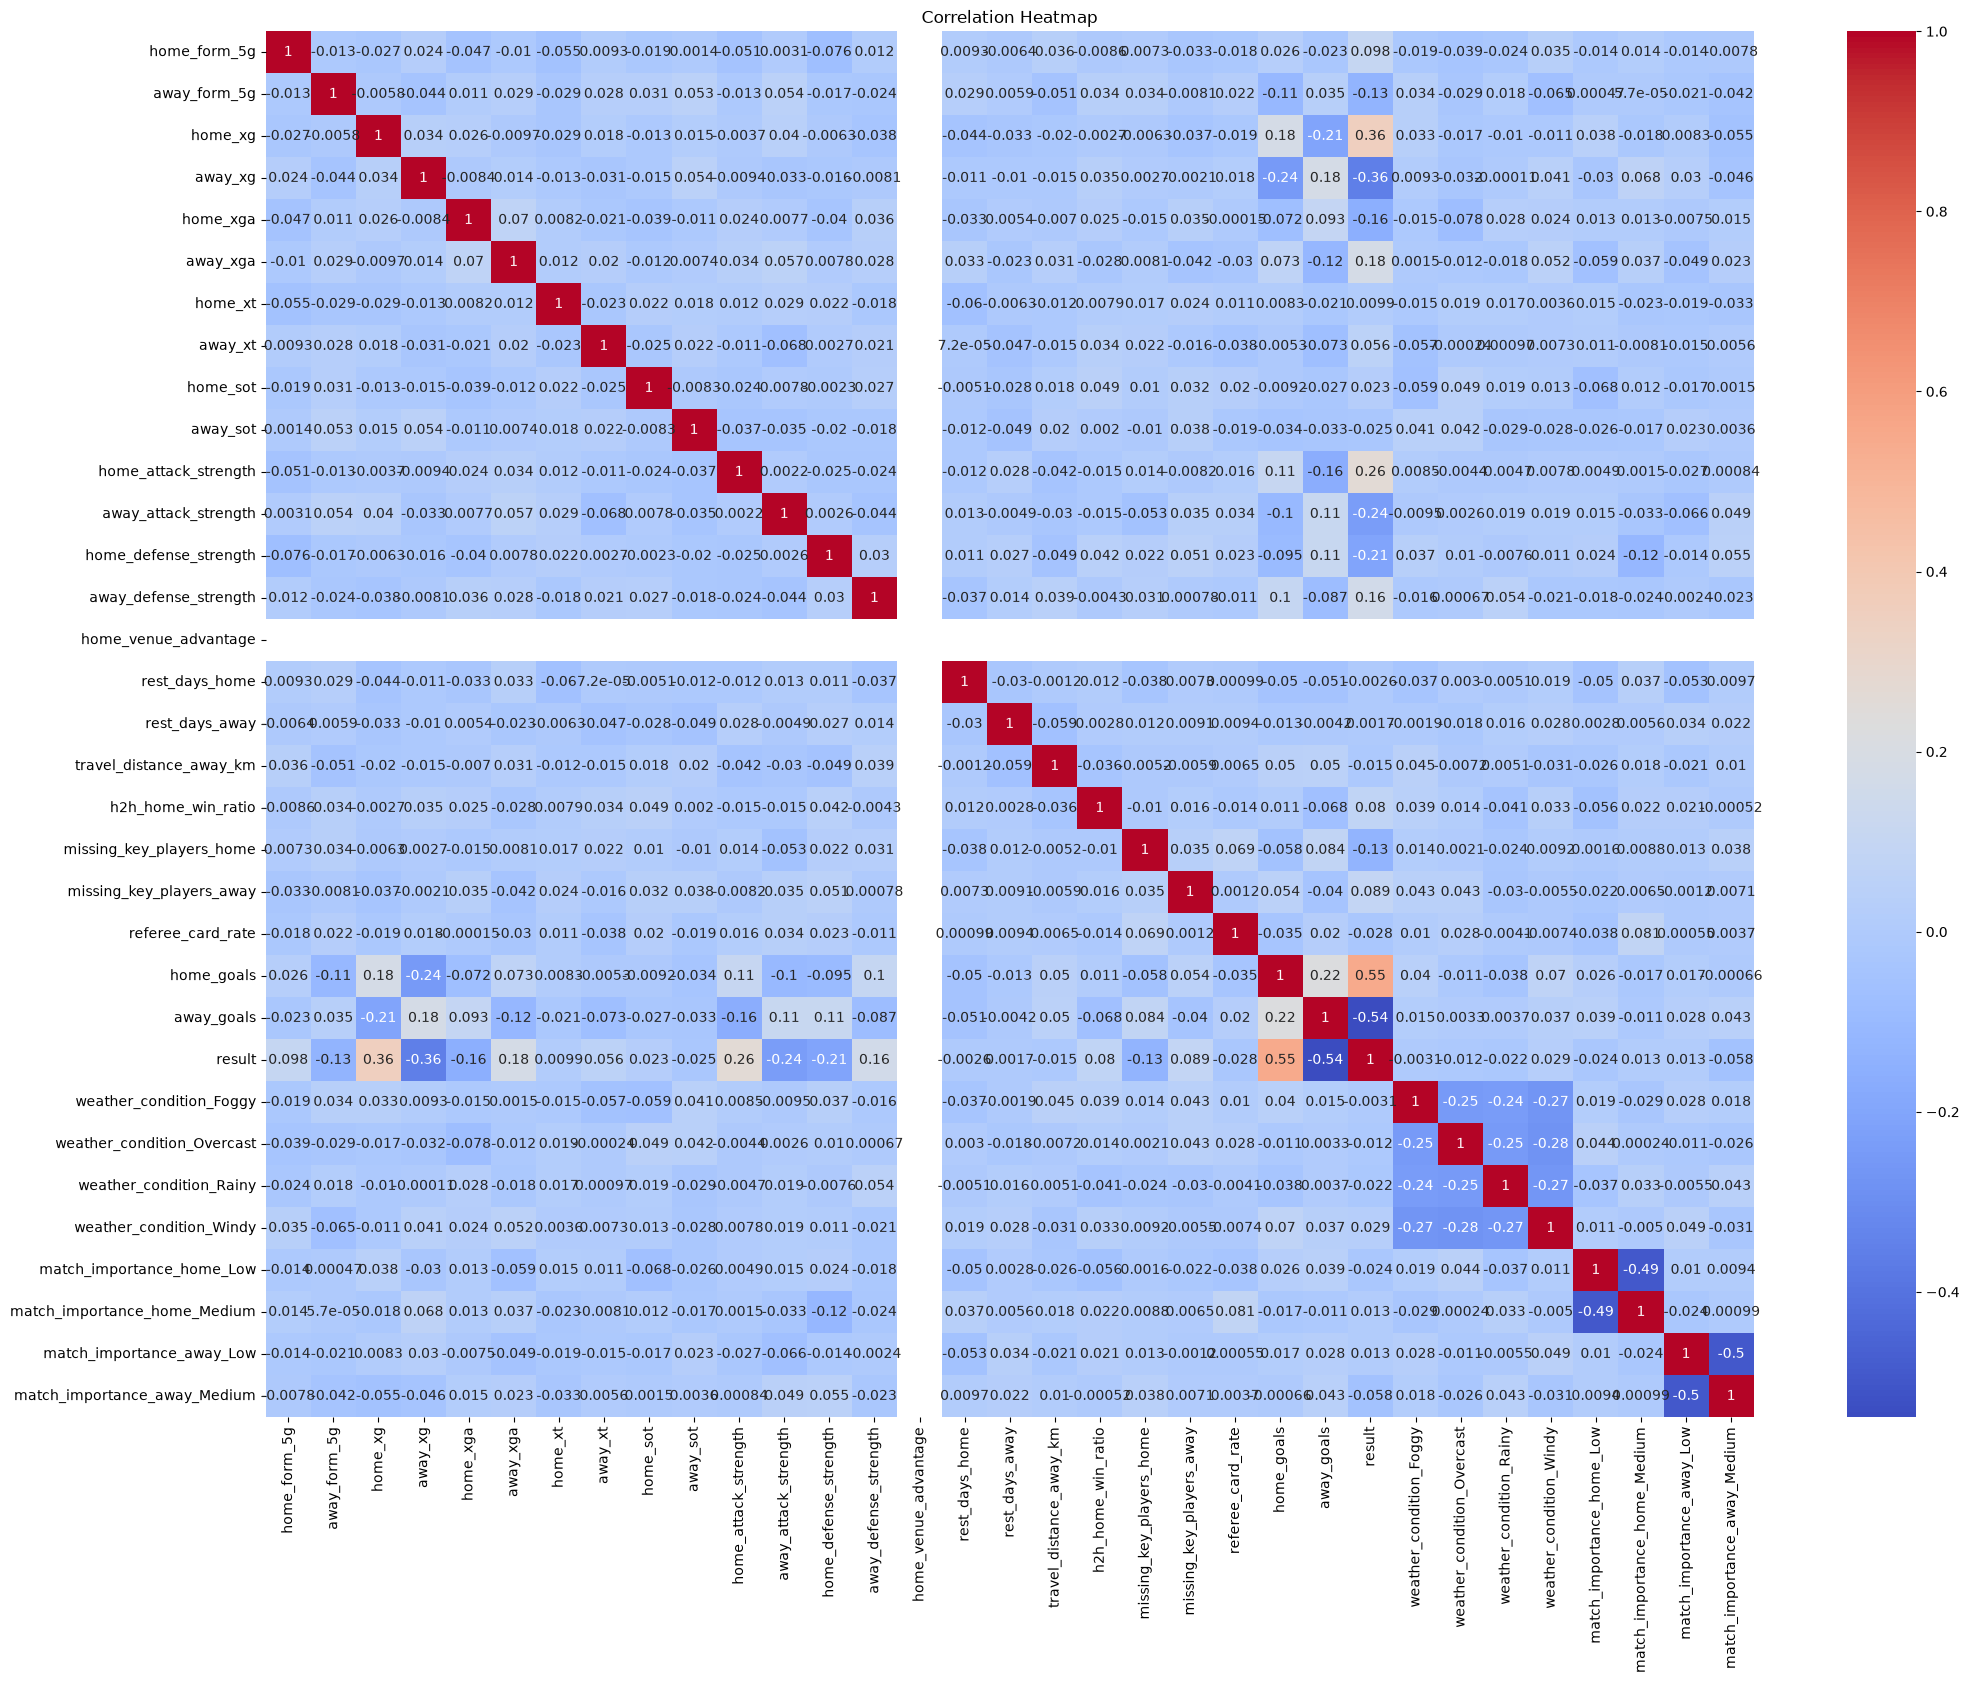

In [10]:
#Correlation heatmap
plt.figure(figsize=(24,18))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
#plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [11]:
df.columns

Index(['match_id', 'home_team', 'away_team', 'home_form_5g', 'away_form_5g',
       'home_xg', 'away_xg', 'home_xga', 'away_xga', 'home_xt', 'away_xt',
       'home_sot', 'away_sot', 'home_attack_strength', 'away_attack_strength',
       'home_defense_strength', 'away_defense_strength',
       'home_venue_advantage', 'rest_days_home', 'rest_days_away',
       'travel_distance_away_km', 'h2h_home_win_ratio',
       'missing_key_players_home', 'missing_key_players_away',
       'referee_card_rate', 'kickoff_time_uk', 'home_goals', 'away_goals',
       'result', 'weather_condition_Foggy', 'weather_condition_Overcast',
       'weather_condition_Rainy', 'weather_condition_Windy',
       'match_importance_home_Low', 'match_importance_home_Medium',
       'match_importance_away_Low', 'match_importance_away_Medium'],
      dtype='str')

In [12]:
features = ['home_form_5g', 'away_form_5g','home_xg', 'away_xg', 'home_xga', 'away_xga', 
            'home_xt', 'away_xt', 'home_sot', 'away_sot', 'home_attack_strength', 'away_attack_strength', 
            'home_defense_strength', 'away_defense_strength', 'rest_days_home', 'rest_days_away', 'travel_distance_away_km', 'h2h_home_win_ratio', 
            'missing_key_players_home', 'missing_key_players_away', 'referee_card_rate']

x = df[features].values
y = df['result'].values

In [13]:
x.shape

(1002, 21)

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=24, stratify=y)

In [15]:
x_test.shape

(201, 21)

In [16]:
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

In [37]:
# Create the model
Football_Model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,

    # Hyperparameters
    n_estimators=2000,
    learning_rate=0.04,
    max_depth=4,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.80,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=2.0,

    # Performance
    tree_method="hist",
    eval_metric="mlogloss",

    # Other settings
    random_state=42,
    n_jobs=-1
)

# Train the model
Football_Model.fit(x_train, y_train)

# Predictions
y_pred = Football_Model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6418

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.66      0.68        67
           1       0.48      0.57      0.52        67
           2       0.78      0.70      0.74        67

    accuracy                           0.64       201
   macro avg       0.66      0.64      0.65       201
weighted avg       0.66      0.64      0.65       201


Confusion Matrix:
[[44 23  0]
 [16 38 13]
 [ 2 18 47]]


In [38]:
importance = pd.DataFrame({
    "Feature": df[features].columns,
    "Importance": Football_Model.feature_importances_
})

print(importance.sort_values("Importance", ascending=False))

                     Feature  Importance
3                    away_xg    0.091950
2                    home_xg    0.076828
11      away_attack_strength    0.063686
10      home_attack_strength    0.057296
12     home_defense_strength    0.056609
5                   away_xga    0.054782
1               away_form_5g    0.052188
4                   home_xga    0.050763
13     away_defense_strength    0.045804
17        h2h_home_win_ratio    0.045091
18  missing_key_players_home    0.042210
0               home_form_5g    0.041469
9                   away_sot    0.040279
19  missing_key_players_away    0.040146
7                    away_xt    0.038126
6                    home_xt    0.035304
15            rest_days_away    0.034853
8                   home_sot    0.033958
20         referee_card_rate    0.033568
14            rest_days_home    0.032725
16   travel_distance_away_km    0.032365


In [39]:
#Saving the failure detection model
joblib.dump(Football_Model, 'Football_Model.pkl')
print('Your model has been saved, successfully.')

Your model has been saved, successfully.


In [40]:
Soccer_Prediction = joblib.load('Football_Model.pkl')

In [41]:
new_match = pd.DataFrame([{
    "home_form_5g": 1.00,
    "away_form_5g": 0.87,
    "home_xg": 2.40,
    "away_xg": 1.80,
    "home_xga": 0.20,
    "away_xga": 0.20,
    "home_xt": 2.56,
    "away_xt": 2.20,
    "home_sot": 6.80,
    "away_sot": 5.80,
    "home_attack_strength": 0.82,
    "away_attack_strength": 0.62,
    "home_defense_strength": 0.16,
    "away_defense_strength": 0.16,
    "rest_days_home": 4,
    "rest_days_away": 3,
    "travel_distance_away_km": 0,
    "h2h_home_win_ratio": 0,
    "missing_key_players_home": 0, 
    "missing_key_players_away": 0,
    "referee_card_rate": 3.80,
}])
 
probs = Football_Model.predict_proba(new_match)[0]
pred_class = Football_Model.predict(new_match)[0]
outcome_map = {0: "Away Win", 1: "Draw", 2: "Home Win"}
 
print("\n" + "="*50)
print("              FRANCE VS SPAIN")
print("="*50)
print(f"Away Win Probability : {probs[0]:.3f}")
print(f"Draw Probability     : {probs[1]:.3f}")
print(f"Home Win Probability : {probs[2]:.3f}")
print(f"Prediction    : {outcome_map[pred_class]}")


              FRANCE VS SPAIN
Away Win Probability : 0.021
Draw Probability     : 0.933
Home Win Probability : 0.046
Prediction    : Draw
